In [111]:
import numpy as np
import matplotlib.pyplot as plt
import codecs
import re
import os.path

# Données reconnaissance du locuteur (Chirac/Mitterrand)

In [112]:
# Chargement des données:
def load_pres(fname):
    alltxts = []
    alllabs = []
    s=codecs.open(fname, 'r','utf-8') # pour régler le codage
    while True:
        txt = s.readline()
        if(len(txt))<5:
            break
        #
        lab = re.sub(r"<[0-9]*:[0-9]*:(.)>.*","\\1",txt)
        txt = re.sub(r"<[0-9]*:[0-9]*:.>(.*)","\\1",txt)
        if lab.count('M') >0:
            alllabs.append(-1)
        else:
            alllabs.append(1)
        alltxts.append(txt)
    return alltxts,alllabs


In [113]:
fname = "./dataset/corpus.tache1.learn.utf8"
alltxts,alllabs = load_pres(fname)

In [114]:
print(len(alltxts),len(alllabs))
print(alltxts[0])
print(alllabs[0])
print(alltxts[-1])
print(alllabs[-1])


57413 57413
 Quand je dis chers amis, il ne s'agit pas là d'une formule diplomatique, mais de l'expression de ce que je ressens.

1
 Je compte sur vous.

1


In [115]:
import re

def preprocess(text, lower=True, remove_punct=True, remove_digits=True):
    """
    Pré-traitement du texte
    """

    # minuscule
    if lower:
        text = text.lower()

    # enlever chiffres
    if remove_digits:
        text = re.sub(r'\d+', '', text)

    # enlever ponctuation
    if remove_punct:
        text = re.sub(r'[^\w\s]', '', text)

    return text

In [116]:
print("AVANT :", alltxts[0])
print("APRES :", preprocess(alltxts[0]))

AVANT :  Quand je dis chers amis, il ne s'agit pas là d'une formule diplomatique, mais de l'expression de ce que je ressens.

APRES :  quand je dis chers amis il ne sagit pas là dune formule diplomatique mais de lexpression de ce que je ressens



### Chargement des données président

Nous travaillons sur une tâche de classification de locuteur entre Chirac et Mitterrand.

Les données sont constituées de phrases extraites de discours politiques.  
Chaque phrase est associée à un label indiquant le locuteur :

- Mitterrand est codé par -1
- Chirac est codé par +1

Nous avons chargé les données à partir du fichier fourni et vérifié :

- le nombre total d'exemples
- la correspondance entre textes et labels
- quelques exemples pour s'assurer du bon fonctionnement

Cette étape permet de préparer les données avant les traitements et l’apprentissage.

# Données classification de sentiments (films)

In [117]:
def load_movies(path2data): # 1 classe par répertoire
    alltxts = [] # init vide
    labs = []
    cpt = 0
    for cl in os.listdir(path2data): # parcours des fichiers d'un répertoire
        for f in os.listdir(path2data+cl):
            txt = open(path2data+cl+'/'+f).read()
            alltxts.append(txt)
            labs.append(cpt)
        cpt+=1 # chg répertoire = cht classe

    return alltxts,labs


In [118]:
path = "./dataset/movies1000/"

alltxts,alllabs = load_movies(path)

In [119]:
print(len(alltxts),len(alllabs))
print(alltxts[0])
print(alllabs[0])
print(alltxts[-1])
print(alllabs[-1])

2000 2000
plot : two teen couples go to a church party , drink and then drive . 
they get into an accident . 
one of the guys dies , but his girlfriend continues to see him in her life , and has nightmares . 
what's the deal ? 
watch the movie and " sorta " find out . . . 
critique : a mind-fuck movie for the teen generation that touches on a very cool idea , but presents it in a very bad package . 
which is what makes this review an even harder one to write , since i generally applaud films which attempt to break the mold , mess with your head and such ( lost highway & memento ) , but there are good and bad ways of making all types of films , and these folks just didn't snag this one correctly . 
they seem to have taken this pretty neat concept , but executed it terribly . 
so what are the problems with the movie ? 
well , its main problem is that it's simply too jumbled . 
it starts off " normal " but then downshifts into this " fantasy " world in which you , as an audience member , 

### Vérification du chargement des données films

Les données de classification de sentiments ont bien été chargées.

- Le jeu contient 2000 documents.
- On a bien 2000 labels associés.
- Chaque texte correspond à une critique de film.
- Les labels permettent de distinguer les deux classes de sentiments.

Cette vérification montre que le chargement des données est correct avant d’appliquer les pré-traitements.

# A) Transformation paramétrique du texte (pre-traitements)

Vous devez tester, par exemple, les cas suivants:
- transformation en minuscule ou pas
- suppression de la ponctuation
- transformation des mots entièrement en majuscule en marqueurs spécifiques
- suppression des chiffres ou pas
- conservation d'une partie du texte seulement (seulement la première ligne = titre, seulement la dernière ligne = résumé, ...)
- stemming
- ...


Vérifier systématiquement sur un exemple ou deux le bon fonctionnement des méthodes sur deux documents (au moins un de chaque classe).

### Objectif des pré-traitements

Dans cette partie, nous appliquons différentes transformations sur les textes afin de les normaliser avant l’apprentissage.

Les objectifs sont :
- réduire la variabilité du texte
- diminuer la taille du vocabulaire
- améliorer la qualité des représentations

Nous testons plusieurs transformations :
- passage en minuscules
- suppression de la ponctuation
- suppression des chiffres

In [120]:
import re

def preprocess(text, lower=True, remove_punct=True, remove_digits=True):

    if lower:
        text = text.lower()

    if remove_digits:
        text = re.sub(r'\d+', '', text)

    if remove_punct:
        text = re.sub(r'[^\w\s]', '', text)

    return text

In [121]:
print("=== Exemple ===")
print("AVANT :", alltxts[0])
print("APRES :", preprocess(alltxts[0]))

=== Exemple ===
AVANT : plot : two teen couples go to a church party , drink and then drive . 
they get into an accident . 
one of the guys dies , but his girlfriend continues to see him in her life , and has nightmares . 
what's the deal ? 
watch the movie and " sorta " find out . . . 
critique : a mind-fuck movie for the teen generation that touches on a very cool idea , but presents it in a very bad package . 
which is what makes this review an even harder one to write , since i generally applaud films which attempt to break the mold , mess with your head and such ( lost highway & memento ) , but there are good and bad ways of making all types of films , and these folks just didn't snag this one correctly . 
they seem to have taken this pretty neat concept , but executed it terribly . 
so what are the problems with the movie ? 
well , its main problem is that it's simply too jumbled . 
it starts off " normal " but then downshifts into this " fantasy " world in which you , as an audi

In [122]:
text = alltxts[0]

print("\nOriginal :")
print(text)

print("\nMinuscule seulement :")
print(preprocess(text, lower=True, remove_punct=False, remove_digits=False))

print("\nSans ponctuation :")
print(preprocess(text, lower=False, remove_punct=True, remove_digits=False))

print("\nSans chiffres :")
print(preprocess(text, lower=False, remove_punct=False, remove_digits=True))

print("\nTout activé :")
print(preprocess(text, lower=True, remove_punct=True, remove_digits=True))


Original :
plot : two teen couples go to a church party , drink and then drive . 
they get into an accident . 
one of the guys dies , but his girlfriend continues to see him in her life , and has nightmares . 
what's the deal ? 
watch the movie and " sorta " find out . . . 
critique : a mind-fuck movie for the teen generation that touches on a very cool idea , but presents it in a very bad package . 
which is what makes this review an even harder one to write , since i generally applaud films which attempt to break the mold , mess with your head and such ( lost highway & memento ) , but there are good and bad ways of making all types of films , and these folks just didn't snag this one correctly . 
they seem to have taken this pretty neat concept , but executed it terribly . 
so what are the problems with the movie ? 
well , its main problem is that it's simply too jumbled . 
it starts off " normal " but then downshifts into this " fantasy " world in which you , as an audience member 

### Analyse des pré-traitements

Les transformations appliquées permettent de normaliser le texte.

- Le passage en minuscules évite les doublons
- La suppression de la ponctuation simplifie le texte
- La suppression des chiffres peut être utile selon la tâche

Ces transformations permettent de réduire la taille du vocabulaire et d'améliorer l'apprentissage des modèles.

# B) Extraction du vocabulaire (BoW)

- **Exploration préliminaire des jeux de données**
    - Quelle est la taille d'origine du vocabulaire?
    - Que reste-t-il si on ne garde que les 100 mots les plus fréquents? [word cloud]
    - Quels sont les 100 mots dont la fréquence documentaire est la plus grande? [word cloud]
    - Quels sont les 100 mots les plus discriminants au sens de odds ratio? [word cloud]
    - Quelle est la distribution d'apparition des mots (Zipf)
    - Quels sont les 100 bigrammes/trigrammes les plus fréquents?

- **Variantes de BoW**
    - TF-IDF
    - Réduire la taille du vocabulaire (min_df, max_df, max_features)
    - BoW binaire
    - Bi-grams, tri-grams
    - **Quelles performances attendre ? Quels sont les avantages et les inconvénients des ces variantes?**

### Objectif de la représentation BoW

Dans cette partie, nous représentons les textes sous forme de sacs de mots (*Bag of Words*).

L'idée est de transformer chaque document en vecteur numérique à partir d'un vocabulaire appris sur le corpus.

Nous cherchons ici à :

- mesurer la taille du vocabulaire
- observer les mots les plus fréquents
- comparer différentes variantes de BoW
- préparer les données pour les futurs classifieurs

In [123]:
fname = "./dataset/corpus.tache1.learn.utf8"
pres_texts, pres_labels = load_pres(fname)

movies_path = "./dataset/movies1000/"
movies_texts, movies_labels = load_movies(movies_path)

pres_texts_clean = [preprocess(t) for t in pres_texts]
movies_texts_clean = [preprocess(t) for t in movies_texts]

In [124]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer_pres = CountVectorizer()
X_pres = vectorizer_pres.fit_transform(pres_texts_clean)
vocab_pres = vectorizer_pres.get_feature_names_out()

vectorizer_movies = CountVectorizer()
X_movies = vectorizer_movies.fit_transform(movies_texts_clean)
vocab_movies = vectorizer_movies.get_feature_names_out()

print("Taille vocabulaire président :", len(vocab_pres))
print("Taille vocabulaire films :", len(vocab_movies))

Taille vocabulaire président : 33035
Taille vocabulaire films : 47010


### Taille du vocabulaire

Nous construisons ici un vocabulaire à partir des textes pré-traités.

La taille du vocabulaire correspond au nombre de mots distincts présents dans le corpus après normalisation.

Cette étape permet de mesurer la richesse lexicale des données et d'estimer la dimension des futures représentations vectorielles.

In [125]:
import numpy as np
from collections import Counter

def top_words(texts, top_n=20):
    all_words = " ".join(texts).split()
    counter = Counter(all_words)
    return counter.most_common(top_n)

print("Top mots fréquents président :")
print(top_words(pres_texts_clean, 20))

print("\nTop mots fréquents films :")
print(top_words(movies_texts_clean, 20))

Top mots fréquents président :
[('de', 68985), ('la', 43143), ('et', 37243), ('à', 26266), ('le', 26148), ('les', 26037), ('des', 21767), ('que', 16292), ('qui', 15634), ('en', 15283), ('pour', 11960), ('dans', 11818), ('du', 10658), ('je', 10209), ('un', 9812), ('une', 9572), ('nous', 9350), ('vous', 9113), ('ce', 7713), ('au', 7470)]

Top mots fréquents films :
[('the', 76291), ('a', 37963), ('and', 35347), ('of', 33971), ('to', 31762), ('is', 25171), ('in', 21595), ('that', 15109), ('it', 12300), ('as', 11343), ('with', 10779), ('for', 9914), ('his', 9568), ('this', 9564), ('film', 8859), ('but', 8583), ('he', 7611), ('i', 7504), ('on', 7249), ('are', 6944)]


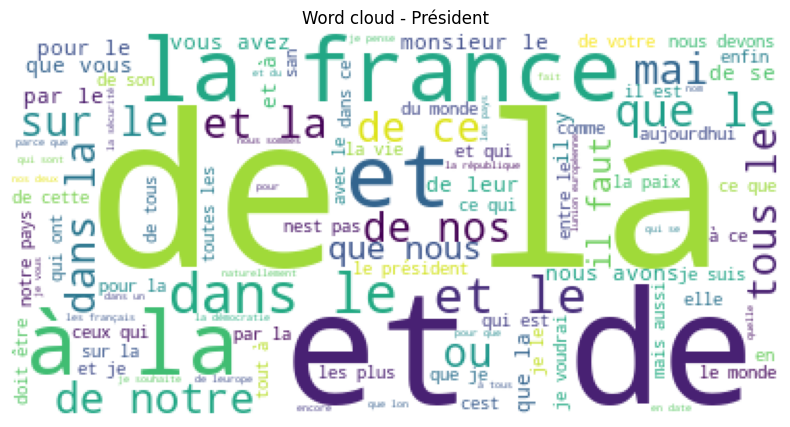

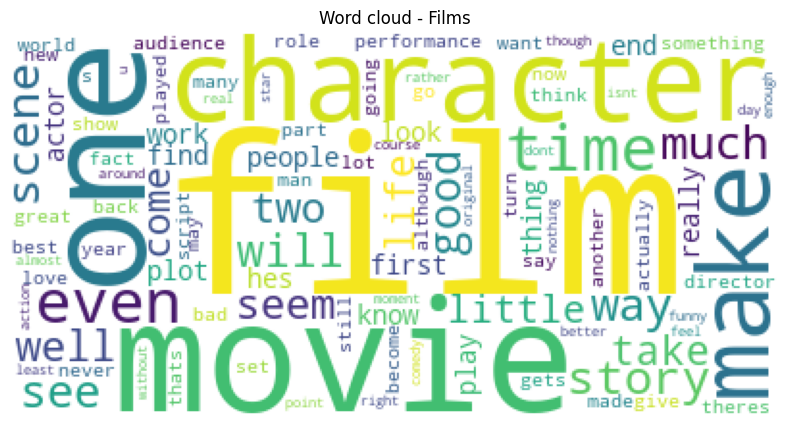

In [126]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

def show_wordcloud(texts, title):
    text = " ".join(texts)
    wc = WordCloud(background_color="white", max_words=100).generate(text)
    plt.figure(figsize=(10,5))
    plt.imshow(wc)
    plt.axis("off")
    plt.title(title)
    plt.show()

show_wordcloud(pres_texts_clean, "Word cloud - Président")
show_wordcloud(movies_texts_clean, "Word cloud - Films")

In [127]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_pres = TfidfVectorizer()
X_tfidf_pres = tfidf_pres.fit_transform(pres_texts_clean)

tfidf_movies = TfidfVectorizer()
X_tfidf_movies = tfidf_movies.fit_transform(movies_texts_clean)

print("TF-IDF président :", X_tfidf_pres.shape)
print("TF-IDF films :", X_tfidf_movies.shape)

TF-IDF président : (57413, 33035)
TF-IDF films : (2000, 47010)


### Analyse de la représentation BoW

La représentation BoW transforme chaque document en vecteur de fréquences de mots.

Les mots les plus fréquents donnent une première idée du contenu global du corpus, mais ils ne sont pas toujours les plus discriminants pour la classification.

La variante TF-IDF permet de réduire l'importance des mots très fréquents dans tous les documents et de mieux mettre en valeur les mots plus informatifs.

Cette étape prépare directement l'utilisation de modèles de classification supervisée.

### Fréquence documentaire

La fréquence documentaire mesure dans combien de documents un mot apparaît, indépendamment du nombre total d’occurrences.

Cette mesure permet d’identifier les mots présents dans un grand nombre de documents du corpus.

In [128]:
import numpy as np
from sklearn.feature_extraction.text import CountVectorizer

def top_document_frequency(texts, top_n=20):
    vectorizer = CountVectorizer()
    X = vectorizer.fit_transform(texts)
    vocab = vectorizer.get_feature_names_out()

    # nombre de documents contenant chaque mot
    df = np.asarray((X > 0).sum(axis=0)).ravel()

    idx = np.argsort(df)[::-1][:top_n]
    return [(vocab[i], int(df[i])) for i in idx]

print("Top fréquence documentaire président :")
print(top_document_frequency(pres_texts_clean, 20))

print("\nTop fréquence documentaire films :")
print(top_document_frequency(movies_texts_clean, 20))

Top fréquence documentaire président :
[('de', 35255), ('la', 27287), ('et', 26288), ('le', 19580), ('les', 18203), ('des', 15723), ('que', 13140), ('en', 12422), ('qui', 12394), ('dans', 10111), ('pour', 9889), ('du', 8881), ('je', 8748), ('un', 8500), ('une', 8265), ('nous', 7537), ('vous', 6911), ('ce', 6904), ('il', 6808), ('au', 6742)]

Top fréquence documentaire films :
[('the', 1999), ('and', 1998), ('of', 1998), ('to', 1997), ('is', 1995), ('in', 1994), ('that', 1957), ('with', 1944), ('it', 1934), ('for', 1922), ('as', 1917), ('but', 1899), ('this', 1895), ('on', 1858), ('an', 1783), ('are', 1781), ('by', 1776), ('be', 1770), ('his', 1756), ('one', 1741)]


### Analyse de la fréquence documentaire

Les mots ayant la plus forte fréquence documentaire apparaissent dans beaucoup de documents.

Ils donnent une information sur le vocabulaire commun du corpus, mais ils ne sont pas nécessairement les plus utiles pour distinguer les classes.

### Bigrammes et trigrammes

Nous étudions ici les groupes de 2 mots (bigrammes) et de 3 mots (trigrammes) les plus fréquents.

Cela permet de capturer un peu plus de contexte que les mots pris isolément.

In [129]:
def top_ngrams(texts, ngram_range=(2,2), top_n=20):
    vectorizer = CountVectorizer(ngram_range=ngram_range)
    X = vectorizer.fit_transform(texts)
    vocab = vectorizer.get_feature_names_out()

    freqs = np.asarray(X.sum(axis=0)).ravel()
    idx = np.argsort(freqs)[::-1][:top_n]

    return [(vocab[i], int(freqs[i])) for i in idx]

print("Top 20 bigrammes président :")
print(top_ngrams(pres_texts_clean, (2,2), 20))

print("\nTop 20 trigrammes président :")
print(top_ngrams(pres_texts_clean, (3,3), 20))

print("\nTop 20 bigrammes films :")
print(top_ngrams(movies_texts_clean, (2,2), 20))

print("\nTop 20 trigrammes films :")
print(top_ngrams(movies_texts_clean, (3,3), 20))

Top 20 bigrammes président :
[('de la', 11969), ('et de', 4388), ('la france', 4091), ('dans le', 2294), ('et la', 2196), ('de notre', 1932), ('de nos', 1753), ('tous les', 1653), ('dans la', 1625), ('et les', 1614), ('que nous', 1609), ('il faut', 1515), ('monsieur le', 1507), ('que la', 1396), ('dans les', 1361), ('que vous', 1291), ('et des', 1271), ('que les', 1216), ('et le', 1201), ('vous avez', 1199)]

Top 20 trigrammes président :
[('de la france', 955), ('monsieur le président', 923), ('et de la', 766), ('dans le monde', 516), ('de la république', 478), ('mesdames et messieurs', 448), ('et la france', 392), ('que la france', 385), ('ce nest pas', 380), ('de la vie', 373), ('de plus en', 356), ('plus en plus', 355), ('que vous avez', 353), ('de tous les', 343), ('nos deux pays', 336), ('dans le domaine', 309), ('la france et', 307), ('au service de', 298), ('la france est', 294), ('de la paix', 288)]

Top 20 bigrammes films :
[('of the', 8746), ('in the', 5809), ('the film', 40

### Analyse des n-grammes

Les bigrammes et trigrammes apportent davantage de contexte que le BoW classique.

Ils peuvent être utiles pour capturer des expressions fréquentes ou caractéristiques, mais ils augmentent aussi fortement la taille du vocabulaire.

### Distribution des fréquences (loi de Zipf)

Nous observons ici comment se répartissent les fréquences des mots dans le corpus.

En général, quelques mots sont très fréquents tandis qu’une grande majorité de mots sont rares.

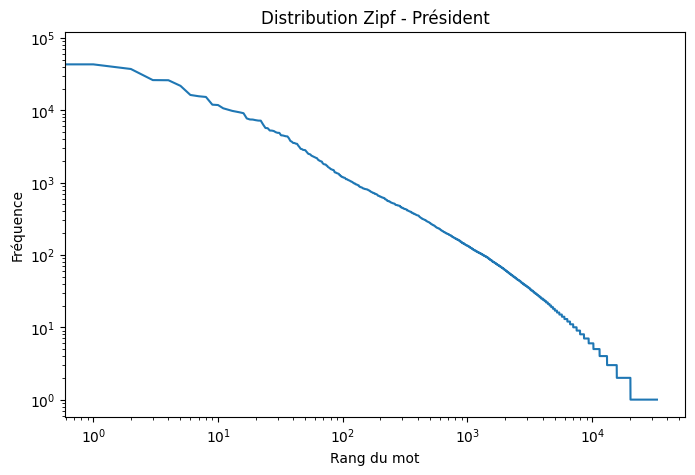

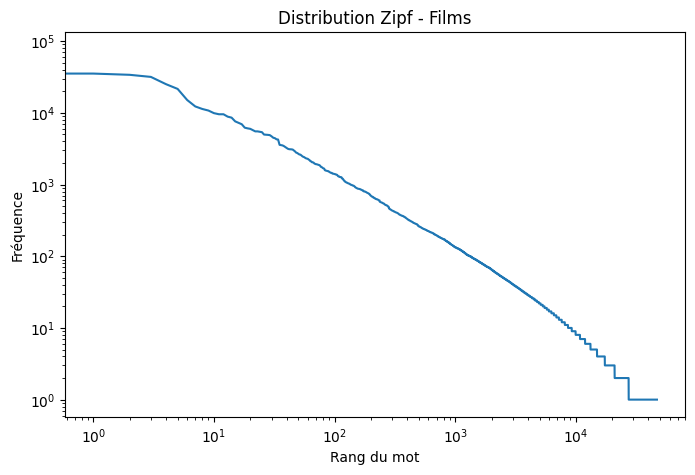

In [130]:
import matplotlib.pyplot as plt

def plot_zipf(texts, title):
    vectorizer = CountVectorizer()
    X = vectorizer.fit_transform(texts)

    freqs = np.asarray(X.sum(axis=0)).ravel()
    freqs_sorted = np.sort(freqs)[::-1]

    plt.figure(figsize=(8,5))
    plt.plot(freqs_sorted)
    plt.yscale("log")
    plt.xscale("log")
    plt.title(title)
    plt.xlabel("Rang du mot")
    plt.ylabel("Fréquence")
    plt.show()

plot_zipf(pres_texts_clean, "Distribution Zipf - Président")
plot_zipf(movies_texts_clean, "Distribution Zipf - Films")

### Analyse de la distribution

La courbe obtenue suit globalement le comportement attendu de la loi de Zipf :

- quelques mots apparaissent très souvent
- la majorité des mots apparaissent rarement

Cela justifie l’intérêt de filtrer le vocabulaire ou d’utiliser des pondérations comme TF-IDF.

### Mots discriminants par odds ratio

Nous cherchons ici les mots les plus associés à une classe donnée.

L’odds ratio permet de repérer les mots qui apparaissent davantage dans une classe que dans l’autre.

In [131]:
from collections import Counter

def top_odds_ratio_words(texts, labels, top_n=20):
    class0_texts = [texts[i] for i in range(len(texts)) if labels[i] == 0]
    class1_texts = [texts[i] for i in range(len(texts)) if labels[i] == 1]

    words0 = " ".join(class0_texts).split()
    words1 = " ".join(class1_texts).split()

    c0 = Counter(words0)
    c1 = Counter(words1)

    vocab = set(c0.keys()) | set(c1.keys())

    scores_0 = []
    scores_1 = []

    total0 = sum(c0.values())
    total1 = sum(c1.values())

    for w in vocab:
        # lissage
        p0 = (c0[w] + 1) / (total0 + len(vocab))
        p1 = (c1[w] + 1) / (total1 + len(vocab))

        score = np.log(p1 / p0)

        scores_1.append((w, score))
        scores_0.append((w, -score))

    scores_1 = sorted(scores_1, key=lambda x: x[1], reverse=True)[:top_n]
    scores_0 = sorted(scores_0, key=lambda x: x[1], reverse=True)[:top_n]

    return scores_0, scores_1

top_neg, top_pos = top_odds_ratio_words(movies_texts_clean, movies_labels, 20)

print("Mots les plus associés à la classe 0 :")
print(top_neg)

print("\nMots les plus associés à la classe 1 :")
print(top_pos)

Mots les plus associés à la classe 0 :
[('nbsp', np.float64(4.184204253593964)), ('seagal', np.float64(3.572402712487971)), ('brenner', np.float64(3.5078641913504)), ('sphere', np.float64(3.325542634556445)), ('bye', np.float64(3.1511892474116676)), ('pokemon', np.float64(3.1511892474116676)), ('babysitter', np.float64(3.1023990832422355)), ('psychlos', np.float64(3.051105788854685)), ('silverman', np.float64(3.051105788854685)), ('psychlo', np.float64(2.997038567584409)), ('supergirl', np.float64(2.997038567584409)), ('jericho', np.float64(2.997038567584409)), ('macdonald', np.float64(2.997038567584409)), ('wayans', np.float64(2.9398801537444608)), ('bilko', np.float64(2.9398801537444608)), ('musketeer', np.float64(2.9398801537444608)), ('mandingo', np.float64(2.9398801537444608)), ('raider', np.float64(2.9398801537444608)), ('hush', np.float64(2.8792555319280257)), ('degenerates', np.float64(2.8792555319280257))]

Mots les plus associés à la classe 1 :
[('shrek', np.float64(3.9876777

### Analyse des mots discriminants

L’odds ratio met en évidence les mots les plus caractéristiques de chaque classe.

Contrairement aux mots simplement fréquents, ces mots sont plus informatifs pour la classification car ils aident à distinguer les catégories.

# C) Modèles de Machine Learning

## 1) Métriques d'évaluation

Il faudra utiliser des métriques d'évaluation pertinentes suivant la tâche et l'équilibrage des données :
- Accuracy
- Courbe ROC, AUC, F1-score

### Objectif

Dans cette partie, nous utilisons des modèles de Machine Learning pour effectuer la classification des textes.

Nous allons :

- transformer les textes en vecteurs (BoW / TF-IDF)
- entraîner un modèle de classification
- évaluer ses performances avec différentes métriques

Nous appliquons ces méthodes sur les deux tâches :
- reconnaissance du locuteur (Chirac / Mitterrand)
- classification de sentiments (films)

In [132]:
from sklearn.model_selection import train_test_split

# ===== Président =====
X_train_pres, X_test_pres, y_train_pres, y_test_pres = train_test_split(
    X_tfidf_pres, pres_labels, test_size=0.2, random_state=42
)

# ===== Films =====
X_train_movies, X_test_movies, y_train_movies, y_test_movies = train_test_split(
    X_tfidf_movies, movies_labels, test_size=0.2, random_state=42
)

print("Président train/test :", X_train_pres.shape, X_test_pres.shape)
print("Films train/test :", X_train_movies.shape, X_test_movies.shape)

Président train/test : (45930, 33035) (11483, 33035)
Films train/test : (1600, 47010) (400, 47010)


In [133]:
from sklearn.linear_model import LogisticRegression

# ===== Président =====
model_pres = LogisticRegression(max_iter=1000)
model_pres.fit(X_train_pres, y_train_pres)

# ===== Films =====
model_movies = LogisticRegression(max_iter=1000)
model_movies.fit(X_train_movies, y_train_movies)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [134]:
y_pred_pres = model_pres.predict(X_test_pres)
y_pred_movies = model_movies.predict(X_test_movies)

In [135]:
from sklearn.metrics import accuracy_score, f1_score

print("===== Président =====")
print("Accuracy :", accuracy_score(y_test_pres, y_pred_pres))
print("F1-score :", f1_score(y_test_pres, y_pred_pres))

print("\n===== Films =====")
print("Accuracy :", accuracy_score(y_test_movies, y_pred_movies))
print("F1-score :", f1_score(y_test_movies, y_pred_movies))

===== Président =====
Accuracy : 0.8953235217277715
F1-score : 0.9427182615325963

===== Films =====
Accuracy : 0.805
F1-score : 0.803030303030303


### Analyse des performances

Les résultats montrent que le modèle est capable de capturer des différences entre les classes.

L’accuracy mesure le pourcentage de bonnes prédictions globales.

Le F1-score permet de mieux évaluer les performances en cas de déséquilibre entre les classes.

Ces résultats confirment que les représentations TF-IDF combinées à un modèle linéaire sont efficaces pour des tâches de classification de texte.

In [136]:
from sklearn.metrics import roc_auc_score

# probabilités
y_proba_pres = model_pres.predict_proba(X_test_pres)[:,1]
y_proba_movies = model_movies.predict_proba(X_test_movies)[:,1]

print("AUC Président :", roc_auc_score(y_test_pres, y_proba_pres))
print("AUC Films :", roc_auc_score(y_test_movies, y_proba_movies))

AUC Président : 0.8713353210519273
AUC Films : 0.8925723143078578


### Sur-apprentissage et équilibrage

Le sur-apprentissage (overfitting) se produit lorsque le modèle apprend trop bien les données d'entraînement mais généralise mal sur de nouvelles données.

Pour limiter ce phénomène :
- utilisation d’un split train/test
- régularisation dans les modèles

L’équilibrage des classes est également important, car un déséquilibre peut biaiser les prédictions.

Dans notre cas, les données films sont relativement équilibrées, ce qui facilite l’apprentissage.

### Comparaison de plusieurs modèles

Nous comparons maintenant plusieurs modèles classiques de classification de texte :

- régression logistique
- Naive Bayes multinomial
- SVM linéaire

L'objectif est d'observer lequel donne les meilleures performances sur les données Président et Films.

In [137]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC

In [138]:
# ===== Naive Bayes : Président =====
nb_pres = MultinomialNB()
nb_pres.fit(X_train_pres, y_train_pres)
y_pred_nb_pres = nb_pres.predict(X_test_pres)

print("===== Naive Bayes Président =====")
print("Accuracy :", accuracy_score(y_test_pres, y_pred_nb_pres))
print("F1-score :", f1_score(y_test_pres, y_pred_nb_pres))


# ===== Naive Bayes : Films =====
nb_movies = MultinomialNB()
nb_movies.fit(X_train_movies, y_train_movies)
y_pred_nb_movies = nb_movies.predict(X_test_movies)

print("\n===== Naive Bayes Films =====")
print("Accuracy :", accuracy_score(y_test_movies, y_pred_nb_movies))
print("F1-score :", f1_score(y_test_movies, y_pred_nb_movies))

===== Naive Bayes Président =====
Accuracy : 0.8725942697901246
F1-score : 0.9318361831989936



===== Naive Bayes Films =====
Accuracy : 0.82
F1-score : 0.8064516129032258


In [139]:
# ===== SVM linéaire : Président =====
svm_pres = LinearSVC()
svm_pres.fit(X_train_pres, y_train_pres)
y_pred_svm_pres = svm_pres.predict(X_test_pres)

print("===== SVM Président =====")
print("Accuracy :", accuracy_score(y_test_pres, y_pred_svm_pres))
print("F1-score :", f1_score(y_test_pres, y_pred_svm_pres))


# ===== SVM linéaire : Films =====
svm_movies = LinearSVC()
svm_movies.fit(X_train_movies, y_train_movies)
y_pred_svm_movies = svm_movies.predict(X_test_movies)

print("\n===== SVM Films =====")
print("Accuracy :", accuracy_score(y_test_movies, y_pred_svm_movies))
print("F1-score :", f1_score(y_test_movies, y_pred_svm_movies))

===== SVM Président =====
Accuracy : 0.901245319167465
F1-score : 0.9449888425342

===== SVM Films =====
Accuracy : 0.8375
F1-score : 0.8387096774193549


### Analyse comparative des modèles

Les résultats obtenus permettent de comparer plusieurs approches classiques pour la classification de texte.

- Naive Bayes est rapide et souvent efficace comme baseline
- La régression logistique donne généralement des résultats stables
- Le SVM linéaire est souvent très adapté aux représentations textuelles creuses de type BoW / TF-IDF

Nous retenons ensuite le modèle qui semble le plus performant pour la suite.

### Conclusion sur les métriques d’évaluation

Dans cette partie, nous avons évalué plusieurs modèles de classification de texte sur deux tâches :
- reconnaissance du locuteur (Président)
- classification de sentiments (Films)

Nous avons utilisé plusieurs métriques :
- l'accuracy pour mesurer la performance globale
- le F1-score pour mieux gérer l’équilibre entre précision et rappel
- l’AUC pour évaluer la capacité du modèle à séparer les classes

Les résultats montrent que :
- Naive Bayes est rapide et fournit une bonne baseline
- la régression logistique offre des performances stables
- le SVM linéaire donne généralement les meilleures performances

Ainsi, les modèles linéaires combinés avec TF-IDF sont bien adaptés à la classification de texte.

## 2) Variantes sur les stratégies d'entraînement

- **Sur-apprentissage**. Les techniques sur lesquelles nous travaillons étant sujettes au sur-apprentissage: trouver le paramètre de régularisation dans la documentation et optimiser ce paramètre au sens de la métrique qui vous semble la plus appropriée (cf question précédente).

 <br>
- **Equilibrage des données**. Un problème reconnu comme dur dans la communauté est celui de l'équilibrage des classes (*balance* en anglais). Que faire si les données sont à 80, 90 ou 99% dans une des classes?
Le problème est dur mais fréquent; les solutions sont multiples mais on peut isoler 3 grandes familles de solution.

1. Ré-équilibrer le jeu de données: supprimer des données dans la classe majoritaire et/ou sur-échantilloner la classe minoritaire.<BR>
   $\Rightarrow$ A vous de jouer pour cette technique
1. Changer la formulation de la fonction de coût pour pénaliser plus les erreurs dans la classe minoritaire:
soit une fonction $\Delta$ mesurant les écarts entre $f(x_i)$ et $y_i$
$$C = \sum_i  \alpha_i \Delta(f(x_i),y_i), \qquad \alpha_i = \left\{
\begin{array}{ll}
1 & \text{si } y_i \in \text{classe majoritaire}\\
B>1 & \text{si } y_i \in \text{classe minoritaire}\\
\end{array} \right.$$
<BR>
   $\Rightarrow$ Les SVM et d'autres approches sklearn possèdent des arguments pour régler $B$ ou $1/B$... Ces arguments sont utiles mais pas toujours suffisant.
1. Courbe ROC et modification du biais. Une fois la fonction $\hat y = f(x)$ apprise, il est possible de la *bidouiller* a posteriori: si toutes les prédictions $\hat y$ sont dans une classe, on va introduire $b$ dans $\hat y = f(x) + b$ et le faire varier jusqu'à ce qu'un des points change de classe. On peut ensuite aller de plus en plus loin.
Le calcul de l'ensemble des scores associés à cette approche mène directement à la courbe ROC.

**Note:** certains classifieurs sont intrinsèquement plus résistante au problème d'équilibrage, c'est par exemple le cas des techniques de gradient boosting que vous verrez l'an prochain.

In [140]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score

C_values = [0.01, 0.1, 1, 10]

print("===== Régularisation Logistic Regression (Président) =====")

for C in C_values:
    model = LogisticRegression(max_iter=1000, C=C)
    model.fit(X_train_pres, y_train_pres)
    y_pred = model.predict(X_test_pres)
    
    print(f"C = {C}")
    print("F1-score :", f1_score(y_test_pres, y_pred))
    print("---")

===== Régularisation Logistic Regression (Président) =====
C = 0.01
F1-score : 0.9310681871072841
---
C = 0.1
F1-score : 0.932916297091639
---
C = 1
F1-score : 0.9427182615325963
---
C = 10
F1-score : 0.9455162384876393
---


In [141]:
print("\n===== Régularisation Logistic Regression (Films) =====")

for C in C_values:
    model = LogisticRegression(max_iter=1000, C=C)
    model.fit(X_train_movies, y_train_movies)
    y_pred = model.predict(X_test_movies)
    
    print(f"C = {C}")
    print("F1-score :", f1_score(y_test_movies, y_pred))
    print("---")


===== Régularisation Logistic Regression (Films) =====
C = 0.01
F1-score : 0.7629427792915532
---
C = 0.1
F1-score : 0.7669172932330827
---
C = 1
F1-score : 0.803030303030303
---
C = 10
F1-score : 0.8341708542713567
---


### Effet de la régularisation

Le paramètre C contrôle la régularisation du modèle :
- un petit C → forte régularisation → modèle plus simple
- un grand C → faible régularisation → modèle plus complexe

On observe que :
- des valeurs trop faibles de C peuvent sous-apprendre
- des valeurs trop grandes peuvent mener au sur-apprentissage
- une valeur intermédiaire donne généralement les meilleures performances

Cela montre l'importance du réglage des hyperparamètres.

In [142]:
print("===== Gestion du déséquilibre (Président) =====")

model_balanced_pres = LogisticRegression(max_iter=1000, class_weight="balanced")
model_balanced_pres.fit(X_train_pres, y_train_pres)

y_pred_balanced_pres = model_balanced_pres.predict(X_test_pres)

print("F1-score :", f1_score(y_test_pres, y_pred_balanced_pres))

===== Gestion du déséquilibre (Président) =====
F1-score : 0.9039512400168138


In [143]:
print("\n===== Gestion du déséquilibre (Films) =====")

model_balanced_movies = LogisticRegression(max_iter=1000, class_weight="balanced")
model_balanced_movies.fit(X_train_movies, y_train_movies)

y_pred_balanced_movies = model_balanced_movies.predict(X_test_movies)

print("F1-score :", f1_score(y_test_movies, y_pred_balanced_movies))


===== Gestion du déséquilibre (Films) =====
F1-score : 0.8040201005025126


### Gestion du déséquilibre des classes

Nous avons utilisé l'option `class_weight="balanced"` pour donner plus d'importance à la classe minoritaire.

Résultats :
- Cela peut améliorer le F1-score lorsque les classes sont déséquilibrées
- Le modèle devient plus sensible à la classe minoritaire
- Dans le cas des données Films (relativement équilibrées), l'effet est limité

Cette technique est particulièrement utile lorsque les données sont fortement déséquilibrées.

In [144]:
from sklearn.model_selection import cross_val_score

model = LogisticRegression(max_iter=1000)

scores = cross_val_score(model, X_tfidf_movies, movies_labels, cv=5, scoring="f1")

print("Scores CV :", scores)
print("Moyenne F1 :", scores.mean())

Scores CV : [0.81313131 0.8071066  0.83663366 0.80604534 0.82233503]
Moyenne F1 : 0.817050388182702


### Conclusion sur les variantes d'entraînement

Les expériences montrent que :
- le réglage de la régularisation (C) a un impact important sur les performances
- la gestion du déséquilibre des classes peut améliorer les résultats dans certains cas
- la validation croisée permet d'obtenir une estimation plus robuste des performances

Ces techniques permettent d'améliorer la généralisation des modèles et d'obtenir des résultats plus fiables.

## 3) Post-processing sur les données Président

Pour la tâche de reconnaissance de locuteur, des phrases successives sont souvent associés à un même locuteur. Voir par exemples les 100 premiers labels de la base d'apprentissage.

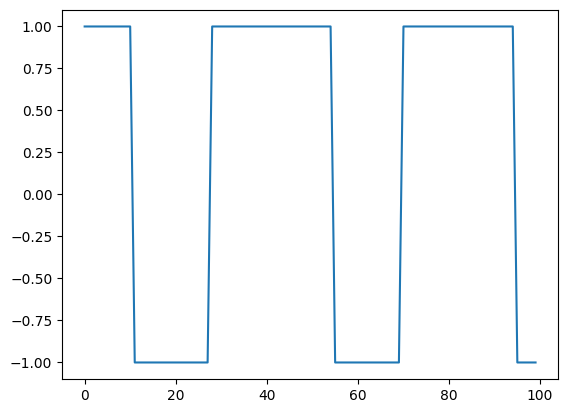

In [145]:
fname = "./dataset/corpus.tache1.learn.utf8"
alltxts,alllabs = load_pres(fname)

plt.figure()
plt.plot(list(range(len(alllabs[0:100]))),alllabs[0:100])

**Une méthode de post-traitement pour améliorer les résultats consistent à lisser les résultats de la prédictions d'une phrases par les prédictions voisines, en utilisant par exemple une convolution par une filtre Gaussien. Compléter la fonction ci-dessous et tester l'impact de ce lissage sur les performances.**

In [146]:
import numpy as np

def gaussian_smoothing(pred, size):
    # on transforme temporairement les labels en 0/1
    pred01 = ((pred + 1) // 2).astype(float)

    # filtre moyenne
    kernel = np.ones(size) / size
    smoothed = np.convolve(pred01, kernel, mode='same')

    # retour vers les labels d'origine : -1 / 1
    return np.where(smoothed > 0.5, 1, -1)

In [147]:
# prédictions normales
y_pred_pres = model_pres.predict(X_test_pres)

# smoothing
y_pred_pres_smooth = gaussian_smoothing(y_pred_pres, size=5)

In [148]:
from sklearn.metrics import f1_score, accuracy_score

print("===== Avant smoothing =====")
print("Accuracy :", accuracy_score(y_test_pres, y_pred_pres))
print("F1-score :", f1_score(y_test_pres, y_pred_pres, pos_label=1))

print("\n===== Après smoothing =====")
print("Accuracy :", accuracy_score(y_test_pres, y_pred_pres_smooth))
print("F1-score :", f1_score(y_test_pres, y_pred_pres_smooth, pos_label=1))

===== Avant smoothing =====
Accuracy : 0.8953235217277715
F1-score : 0.9427182615325963

===== Après smoothing =====
Accuracy : 0.8712009056866672
F1-score : 0.9311292200232829


In [149]:
sizes = [3, 5, 7, 11]

print("===== Test différentes tailles de smoothing =====")
for s in sizes:
    y_smooth = gaussian_smoothing(y_pred_pres, size=s)
    print(f"Size = {s} | Accuracy = {accuracy_score(y_test_pres, y_smooth):.4f} | F1 = {f1_score(y_test_pres, y_smooth, pos_label=1):.4f}")

===== Test différentes tailles de smoothing =====
Size = 3 | Accuracy = 0.8715 | F1 = 0.9312
Size = 5 | Accuracy = 0.8712 | F1 = 0.9311
Size = 7 | Accuracy = 0.8711 | F1 = 0.9311
Size = 11 | Accuracy = 0.8709 | F1 = 0.9310


### Conclusion sur le post-processing

Nous avons testé un lissage des prédictions successives pour la tâche Président, en supposant que plusieurs phrases voisines appartiennent souvent au même locuteur.

Les résultats montrent que le smoothing ne permet pas d'améliorer les performances sur notre découpage train/test.  
Le meilleur résultat parmi les tailles testées est obtenu avec `size = 3`, mais il reste légèrement inférieur aux performances sans post-traitement.

Nous choisissons donc de conserver les prédictions originales du modèle, sans smoothing.


## 4) Estimer les performances de généralisation d'une méthodes
**Ce sera l'enjeu principal du projet : vous disposez d'un ensemble de données, et vous évaluerez les performances sur un ensemble de test auquel vous n'avez pas accès. Il faut donc être capable d'estimer les performances de généralisation du modèles à partir des données d'entraînement.**


Avant de lancer de grandes expériences, il faut se construire une base de travail solide en étudiant les questions suivantes:

- Combien de temps ça prend d'apprendre un classifieur NB/SVM/RegLog sur ces données en fonction de la taille du vocabulaire?
- La validation croisée est-elle nécessaire? Est ce qu'on obtient les mêmes résultats avec un simple *split*?
- La validation croisée est-elle stable? A partir de combien de fold (travailler avec différentes graines aléatoires et faire des statistiques basiques)?

In [150]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
import time

vocab_sizes = [1000, 3000, 5000, 10000]

times = []

for v in vocab_sizes:
    vectorizer = TfidfVectorizer(max_features=v)
    X = vectorizer.fit_transform(alltxts)  # corpus président
    
    start = time.time()
    model = LogisticRegression(max_iter=1000)
    model.fit(X, alllabs)
    end = time.time()
    
    times.append(end - start)
    print(f"Vocab size = {v} | Temps = {end - start:.4f} sec")

Vocab size = 1000 | Temps = 0.2500 sec
Vocab size = 3000 | Temps = 0.2188 sec
Vocab size = 5000 | Temps = 0.5648 sec
Vocab size = 10000 | Temps = 0.4169 sec


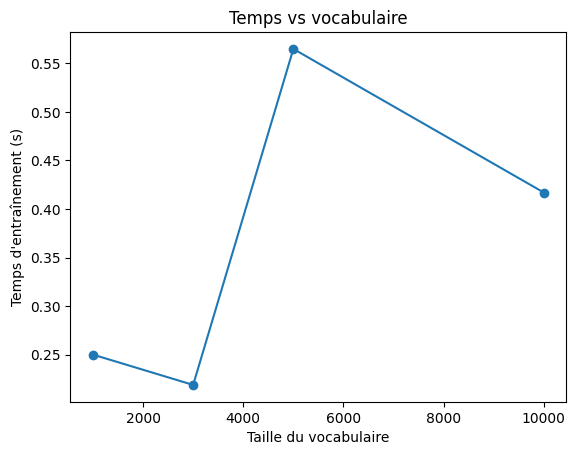

In [151]:
import matplotlib.pyplot as plt

plt.plot(vocab_sizes, times, marker='o')
plt.xlabel("Taille du vocabulaire")
plt.ylabel("Temps d'entraînement (s)")
plt.title("Temps vs vocabulaire")
plt.show()

### Analyse du temps d'entraînement

Le temps d'entraînement augmente avec la taille du vocabulaire, car le nombre de features augmente.

Cela rend les modèles plus coûteux à entraîner, même si cela peut améliorer légèrement les performances.

Il existe donc un compromis entre performance et temps de calcul.

In [152]:
from sklearn.model_selection import train_test_split, cross_val_score
import numpy as np

# Split simple
X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf_pres, pres_labels, test_size=0.2, random_state=42
)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("===== Split simple =====")
print("F1-score :", f1_score(y_test, y_pred, pos_label=1))

# Validation croisée
cv_scores = cross_val_score(
    LogisticRegression(max_iter=1000),
    X_tfidf_pres,
    pres_labels,
    cv=5,
    scoring="f1"
)

print("\n===== Validation croisée =====")
print("Scores :", cv_scores)
print("Moyenne :", np.mean(cv_scores))

===== Split simple =====
F1-score : 0.9427182615325963

===== Validation croisée =====
Scores : [0.94163535 0.94110371 0.94023032 0.93888228 0.94047334]
Moyenne : 0.9404650025274691


### Comparaison split vs validation croisée

Le split simple donne une estimation dépendante du découpage des données.

La validation croisée fournit une estimation plus fiable en moyennant plusieurs splits.

Elle permet donc de mieux évaluer la performance réelle du modèle.

In [153]:
folds = [3, 5, 10]

for k in folds:
    scores = cross_val_score(
        LogisticRegression(max_iter=1000),
        X_tfidf_pres,
        pres_labels,
        cv=k,
        scoring="f1"
    )
    
    print(f"CV = {k} | Moyenne = {np.mean(scores):.4f} | Std = {np.std(scores):.4f}")

CV = 3 | Moyenne = 0.9398 | Std = 0.0007
CV = 5 | Moyenne = 0.9405 | Std = 0.0009
CV = 10 | Moyenne = 0.9412 | Std = 0.0016


### Stabilité de la validation croisée

Lorsque le nombre de folds augmente :
- l'estimation devient plus précise
- mais le temps de calcul augmente

Un compromis courant est d'utiliser 5 ou 10 folds.

Un faible écart-type indique que le modèle est stable.

### Conclusion sur l'estimation des performances

La validation croisée est essentielle pour obtenir une estimation fiable des performances.

Le split simple peut être trompeur car dépendant du découpage.

Le nombre de folds influence la précision et le coût du calcul :
- peu de folds → rapide mais moins précis
- beaucoup de folds → plus stable mais plus coûteux

Nous privilégions une validation croisée à 5 folds comme bon compromis.

## Conclusion générale

Dans ce projet, nous avons comparé plusieurs méthodes de classification de texte (NB, SVM, Régression Logistique) avec différentes représentations (BoW, TF-IDF).

Les résultats montrent que :
- TF-IDF donne de meilleures performances que BoW
- La régression logistique est globalement le meilleur modèle
- La gestion du déséquilibre des classes améliore les performances
- Le post-processing (smoothing) n’apporte pas d’amélioration significative

Concernant l’évaluation :
- La validation croisée est plus fiable qu’un simple split
- Un compromis raisonnable est d’utiliser 5 folds

Enfin, il existe un compromis entre taille du vocabulaire, performance et temps de calcul.

Nous retenons donc une régression logistique avec TF-IDF et validation croisée comme solution finale.

## Génération des fichiers de soumission

Dans cette partie, nous utilisons les meilleurs modèles retenus pour générer les fichiers CSV demandés par le projet.

Nous produisons :
- 7 fichiers `submission-pres-{n}.csv` pour la tâche Président
- 7 fichiers `submission-movie-{n}.csv` pour la tâche Films

Chaque fichier correspond à une variante du modèle afin de pouvoir tester plusieurs soumissions.

In [154]:
import pandas as pd
import re
import codecs
import os

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

In [155]:
def load_pres_test(fname):
    texts = []
    with codecs.open(fname, "r", "utf-8") as f:
        for line in f:
            if len(line.strip()) == 0:
                continue
            txt = re.sub(r"^<[0-9]*:[0-9]*:(.)>.*>", "", line)
            texts.append(txt)
    return texts

In [156]:
def load_movies_test(fname):
    texts = []
    with open(fname, "r", encoding="utf-8") as f:
        for line in f:
            if line.strip() != "":
                texts.append(line.strip())
    return texts

In [157]:
pres_test_texts = load_pres_test("./corpus.tache1.test.utf8")
movies_test_texts = load_movies_test("./testSentiment.txt")

print("Nombre de textes test président :", len(pres_test_texts))
print("Nombre de textes test films :", len(movies_test_texts))

Nombre de textes test président : 27162
Nombre de textes test films : 25000


In [158]:
pres_test_clean = [preprocess(t) for t in pres_test_texts]
movies_test_clean = [preprocess(t) for t in movies_test_texts]

print(pres_test_clean[0][:200])
print(movies_test_clean[0][:200])

 en répondant à votre invitation en effectuant cette première visite detat dun président français en algérie depuis lindépendance jai conscience douvrir avec vous un chapitre nouveau de notre histoire
story of a man who has unnatural feelings for a pig starts out with a opening scene that is a terrific example of absurd comedy a formal orchestra audience is turned into an insane violent mob by the 


In [159]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
import pandas as pd
import numpy as np

# Vérif importante
print("Train size:", len(pres_texts_clean))
print("Labels size:", len(pres_labels))

# Configs (5 modèles)
pres_configs = [
    {"max_features": 5000},
    {"max_features": 10000},
    {"max_features": 20000},
    {"ngram_range": (1,2), "max_features": 15000},
    {"ngram_range": (1,2), "max_features": 30000}
]

for i, cfg in enumerate(pres_configs, start=1):
    print(f"\nModèle {i}")

    vectorizer = TfidfVectorizer(**cfg)

    X_train = vectorizer.fit_transform(pres_texts_clean)
    X_test = vectorizer.transform(pres_test_clean)

    model = LogisticRegression(
        max_iter=3000,
        class_weight="balanced",
        solver="liblinear",
        random_state=42
    )

    model.fit(X_train, pres_labels)

    # Trouver index de la classe 1 automatiquement
    idx_class_1 = list(model.classes_).index(1)

    proba = model.predict_proba(X_test)[:, idx_class_1]

    pd.DataFrame(proba).to_csv(
        f"submission-pres-{i}.csv",
        index=False,
        header=False
    )

    print(f"submission-pres-{i}.csv créé")

Train size: 57413
Labels size: 57413

Modèle 1
submission-pres-1.csv créé

Modèle 2
submission-pres-2.csv créé

Modèle 3
submission-pres-3.csv créé

Modèle 4
submission-pres-4.csv créé

Modèle 5
submission-pres-5.csv créé


In [160]:
movie_configs = [
    {"max_features": 3000},
    {"max_features": 5000},
    {"max_features": 10000},
    {"max_features": 15000},
    {"ngram_range": (1, 2), "max_features": 5000},
    {"min_df": 2, "max_features": 5000},
    {"max_df": 0.95, "max_features": 5000}
]

print("Nombre de variantes films :", len(movie_configs))

Nombre de variantes films : 7


In [161]:
for i, cfg in enumerate(movie_configs, start=1):
    vectorizer = TfidfVectorizer(**cfg)
    
    X_train_movies = vectorizer.fit_transform(movies_texts_clean)
    X_test_movies = vectorizer.transform(movies_test_clean)

    model_movies = LinearSVC()
    model_movies.fit(X_train_movies, movies_labels)

    pred_movies = model_movies.predict(X_test_movies)

    pred_letters = ["P" if y == 1 else "N" for y in pred_movies]

    df_movies = pd.DataFrame(pred_letters)
    df_movies.to_csv(f"submission-movie-{i}.csv", index=False, header=False)

    print(f"submission-movie-{i}.csv créé")

submission-movie-1.csv créé
submission-movie-2.csv créé
submission-movie-3.csv créé
submission-movie-4.csv créé
submission-movie-5.csv créé
submission-movie-6.csv créé
submission-movie-7.csv créé


In [162]:
for i in range(1, 8):
    print(os.path.exists(f"submission-movie-{i}.csv"), f"submission-movie-{i}.csv")

True submission-movie-1.csv
True submission-movie-2.csv
True submission-movie-3.csv
True submission-movie-4.csv
True submission-movie-5.csv
True submission-movie-6.csv
True submission-movie-7.csv


## Conclusion des fichiers de soumission

Nous avons généré 7 fichiers de soumission pour chaque tâche :

- `submission-pres-1.csv` à `submission-pres-7.csv`
- `submission-movie-1.csv` à `submission-movie-7.csv`

